# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 1: Rewriting functions...*) - Plot $f(x)$ vs. $x$ using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
    - (See Problem 2) Why do the "bad" and "good" formulas of the quadratic roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Layugan, Nathanael Dewel
- _Student No._: 2024-00534
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

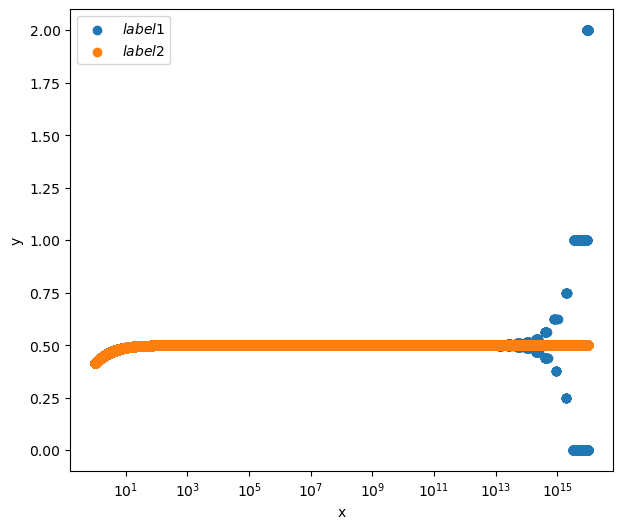

In [42]:
import numpy as np 
import matplotlib.pyplot as plt

# Original Function
def f_original(x):
    return (np.sqrt(x**2 +x)) - x

# (Via Algebraic Conjugate) [Get Product with Conjugate (difference of squares), divide by the Conjugate]
def f_stable(x):
    return x / (np.sqrt(x**2 +x) + x)

x_list = np.geomspace(1, 1e16, 100000)

y_original = f_original(x_list)
y_stable = f_stable(x_list)

fig, ax = plt.subplots(figsize = (7,6))
ax.scatter(x_list, y_original, label = r'$label 1$')
ax.scatter(x_list, y_stable, label = r'$label 2$')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.set_xscale('log')
ax.legend()

plt.show()

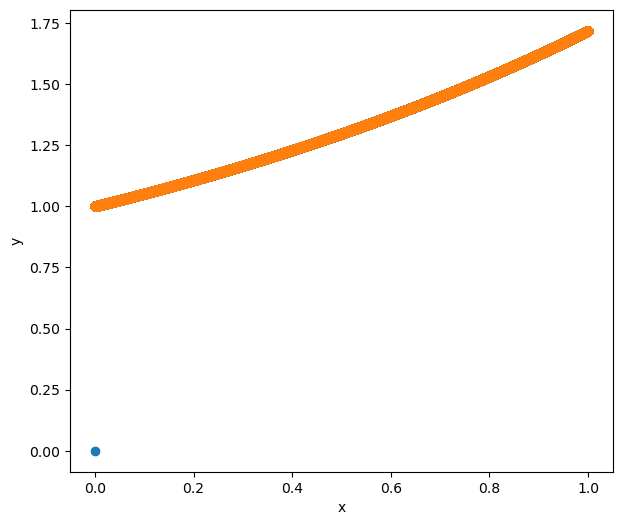

In [43]:
import numpy as np 
import matplotlib.pyplot as plt

# Original Function
def g_original(x):
    return (np.e**x - 1)/ x  

# Using the np.expm1() to solve catastrophic cancellation
def g_stable(x):
    return np.expm1(x)/ x  

x_list = np.linspace(1e-18,1, 100000)

y_original = g_original(x_list)
y_stable = g_stable(x_list)

fig, ax = plt.subplots(figsize = (7,6))
ax.scatter(x_list, y_original, label = r'$label 1$')
ax.scatter(x_list, y_stable, label = r'$label 2$')
ax.set_ylabel('y')
ax.set_xlabel('x')

plt.show()

### Report figure

For the first problem (first figure), the function becomes Catastrophic once it approaches to larger numbers (particularly 10 raised to 13). As the x becomes larger, approaching 10 raised to 16, the Catastrophe becomes more visible on the plot (Blue dots). 

For the second problem (second figure), the function becomes Catastrophic once x is near 0 (extremely small numbers).

### Report discussion

Problem 1 

For the first problem, the function becomes Catastrophic once it approaches to larger numbers (particularly 10 raised to 13). As the x becomes larger, approaching 10 raised to 16, the Catastrophe becomes more visible on the plot (Blue dots). By using the Original Equation, it will return an error, therefore using the original equation is invalid for larger numbers. This problem was solved by using an Algebraic Conjugate. 

For the second problem, the function becomes Catastrophic once x are near 0 (extremely small numbers). For the Original function, As x approached to 0, the value approaches to 0, which is wrong because mathematically it should approach to 1. This problem was solved using a dedicated code in Python that handles exponentials. 

Problem 2 

This is all because of catastrophic cancellation, particularly on the quadratic formula. Observe how the other solution is correct (x_minus), while the other (x_plus) is catastrophic. This is because thhe x_plus solution involves a subtraction operation, therefore leading to a catastrophic cancellation. 

To solve this, it is eager to avoid using subtraction operations, the solution for this particular problem uses division instead, and practically avoiding subtraction, therefore avoiding catastrophic cancellation. 

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.
- hehe


---
## Section 2: Code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Rewriting functions to avoid subtractive cancellation

#### Part 1.1: 

Consider the function $$ f(x) = \sqrt{x^2 + x} - x \tag{1}$$

(a) Start by plotting the function, using a grid of $100$ linearly-spaced points from $0$ to $100$. This should give you some idea of the values you should expect for $f(x)$ at large $x$.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x):
    return (np.sqrt(x**2 +x)) - x)

x_list = np.linspace(0,100,1000000)

plt.plot(x_list,f(x_list))

(b) Verify your previous hunch by taking the limit $x\rightarrow\infty$ and using algebraic conjugate.

(c) Now, see what value you find for Eq. $(1)$ when $x = 10^{16}$. Does this make sense, even qualitatively?

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x):
    return (np.sqrt(x**2 +x)) - x

f(10**16)

(d) Rewrite Eq. $(1)$ to avoid the catastrophic cancellation. Evaluate the new function at $x = 10^{16}$ and compare with your analytical answer for $x \rightarrow \infty$.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

# (Via Algebraic Conjugate) [Get Product with Conjugate (difference of squares), divide by the Conjugate]
def g(x):
    x = float(x) # Converted into a float, as sqrt can't input integer
    return x / (np.sqrt(x**2 +x) + x)

g(10**16)

(e) **[FIGURE]** Plot the $f(x)$ vs. $x$ using the manual evaluation Eq. $(1)$ vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. 

(Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

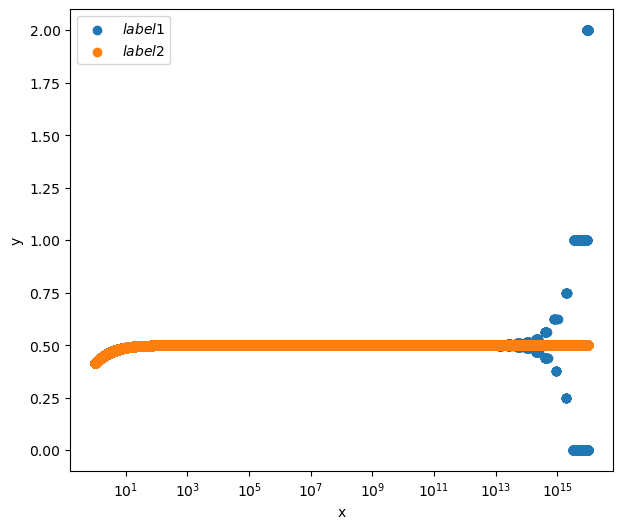

In [38]:
import numpy as np 
import matplotlib.pyplot as plt

# Original Function
def f_original(x):
    return (np.sqrt(x**2 +x)) - x

# (Via Algebraic Conjugate) [Get Product with Conjugate (difference of squares), divide by the Conjugate]
def f_stable(x):
    return x / (np.sqrt(x**2 +x) + x)

x_list = np.geomspace(1, 1e16, 100000)

y_original = f_original(x_list)
y_stable = f_stable(x_list)

fig, ax = plt.subplots(figsize = (7,6))
ax.scatter(x_list, y_original, label = r'$label 1$')
ax.scatter(x_list, y_stable, label = r'$label 2$')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.set_xscale('log')
ax.legend()

plt.savefig("Part_1_Catastrophe_Big_Numbers.png")

plt.show()

In [ ]:
# template for plotting with plt.subplots()

fig, ax = plt.subplots(figsize = (7,6))
ax.scatter(xvals, yvals1, label = r'$label 1$')
ax.scatter(xvals, yvals2, label = r'$label 2$')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.set_xscale('log')
ax.legend()
plt.show()
plt.savefig()

#### Part 1.2: 

Consider the function 
$$ f(x) = \frac{e^x - 1}{x} \tag{2}$$

(a) Start by plotting the function, using a grid of $100$ linearly-spaced points from $0.1$ to $5.0$. This should give you some idea of the values you should expect for $f(x)$ at small $x$.

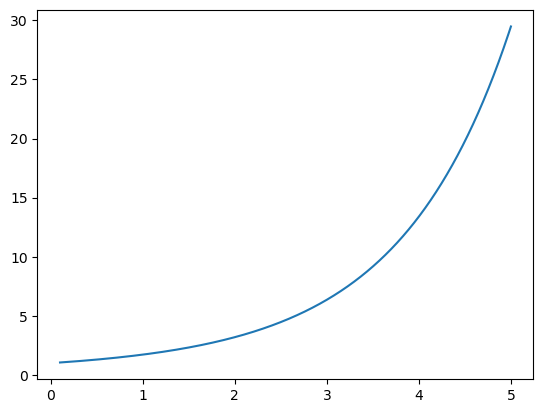

In [7]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x):
    return (np.e**x - 1)/ x  

x_list = np.linspace(0.1,5.0,1000000)

plt.plot(x_list,f(x_list))

(b) Verify your previous hunch by taking the limit $x\rightarrow0$ and using L'Hôpital's rule.

(c) Now, see what value you find for Eq. $(2)$ when $x = 10^{-16}$. Does this make sense, even qualitatively?

In [8]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x):
    return (np.e**x - 1)/ x  

x_list = np.linspace(0.1,5.0,1000000)

f(10**-16)

0.0

(d) In `NumPy`, there is a special function `np.expm1()` that evaluates $e^{x}-1$. How does the function resolve the catastrophic cancellation? Using this function, evaluate Eq. (4) at $x = 10^{-16}$ and compare with your analytical answer for $x \rightarrow 0$.

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

def f(x):
    return np.expm1(x)/ x  

f(10**-16)

1.0

(e) **[FIGURE]** Plot the $f(x)$ vs. $x$ using the manual evaluation Eq. $(2)$ vs. the `np.expm1()` function. In the figure, show the area where the catastrophic cancellation occurs. 

(Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

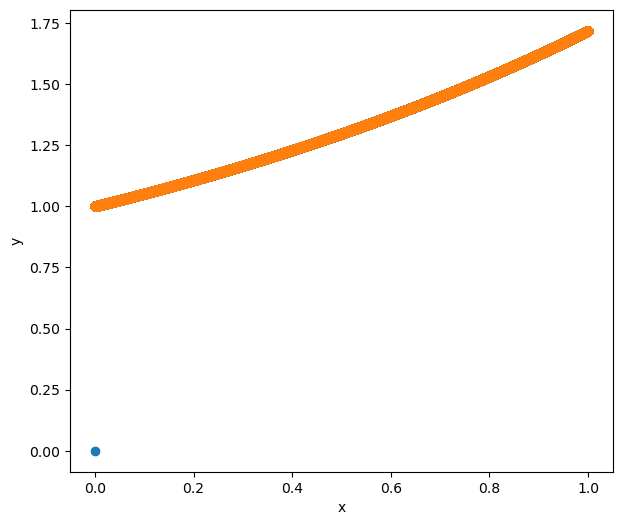

In [39]:
import numpy as np 
import matplotlib.pyplot as plt

# Original Function
def g_original(x):
    return (np.e**x - 1)/ x  

# Using the np.expm1() to solve catastrophic cancellation
def g_stable(x):
    return np.expm1(x)/ x  

x_list = np.linspace(1e-18,1, 100000)

y_original = g_original(x_list)
y_stable = g_stable(x_list)

fig, ax = plt.subplots(figsize = (7,6))
ax.scatter(x_list, y_original, label = r'$label 1$')
ax.scatter(x_list, y_stable, label = r'$label 2$')
ax.set_ylabel('y')
ax.set_xlabel('x')

plt.savefig("Part_1_Catastrophe_Small_Numbers.png")

plt.show()

#### Problem 1 code summary

Both Problems are easily coded by using simple python and numpy functions. The only problem is how handling Catasthropic cancellation, which was solve by avoiding the subtraction operation via Algebraic Conjugate (subtraction causes the cancellation) and using specific numpy function that handles the catastrophic cancellation itself. The exercises actually let me compare the outcomes (by plotting) of a function with and without Catastrophic Cancellation, pinpointing the difference of there outputs. 


### Problem 2: Quadratic Equation (Gezerlis Problem 2.6)

Take the standard quadratic equation: $ax^2 + bx + c = 0$, whose solutions are:
$$
x_\pm = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} \tag{3} 
$$ 
 

Take $b>0$ for concreteness. It is easy to see that when $b^2 \gg ac$ we don’t get
a catastrophic cancellation when evaluating $b^2 −4ac$ (we may still get a “benign”
cancellation). Furthermore, $\sqrt{b^2-4ac}\approx b$. However, this means that $x_+$ will involve
catastrophic cancellation in the numerator. We will employ an analytical trick in
order to help us preserve significant figures. Observe that the product of the two
roots obeys the relation: 

$$x_+x_−=c/a. \tag{4}$$ 

The answer now presents itself: use Eq. $(1)$ to calculate $x_−$, for which no catastrophic cancellation takes place. 
Then, use Eq. $(2)$ to calculate $x_+$. Notice that you ended up calculating $x_+$ via division only (i.e., without a catastrophic cancellation). 

Take $a = 1$, $c = 1$, and $b= 10^8$. Write a Python code that evaluates and prints out the following:

(a) $x_-$ using Eq. $(3)$

In [27]:
from math import sqrt

a, b, c = 1, 1e8, 1

x_minus = (-b - sqrt(b**2 - 4 * a * c)) / (2 * a)
print(x_minus)

-100000000.0


(b) $x_+$ using the “bad” formula -- i.e. Eq. $(3)$

In [26]:
from math import sqrt

a, b, c = 1, 1e8, 1

# Note: x_+ corresponds to the positive sign, which leads to catastrophic cancellation
x_plus_bad = (-b + sqrt(b**2 - 4 * a * c)) / (2 * a)
print(x_plus_bad)

-7.450580596923828e-09


(c) $x_+$ using the “good” formula -- i.e. Eq. $(4)$

In [25]:
from math import sqrt

a, b, c = 1, 1e8, 1

# Since x_+ * x_- = c / a, we get x_+ = c / (a * x_-)
x_plus_good = c / (a * x_minus)
print(x_plus_good)

-1e-08


#### Problem 2 code summary

This code showcases when did Catasthropic cancellation occurs, it shows that specifically it happens due to the subtraction operation. The code just simply types the operation (Quadratic formula), then solves the problem of Catasthropic Cancellation by avoiding the subtraction operation (the solution was given in the problem). 

---
## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))